In [8]:
from google.colab import files
uploaded = files.upload()

Saving freelancer_data.csv to freelancer_data.csv


Now will explore the dataset details

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sbn

In [10]:
df = pd.read_csv ("freelancer_data.csv")
df.head()

,Freelancer_ID,Job_Category,Platform,Experience_Level,Client_Region,Payment_Method,Job_Completed,Earnings_USD,Hourly_Rate,Job_Success_Rate,Client_Rating,Job_Duration_Days,Project_Type,Rehire_Rate,Marketing_Spend
0,1,Content Writing,PeoplePerHour,Beginner,Africa,Crypto,65,511,23.71,61.15,2.46,NaN,Hourly,NaN,99.0
1,2,Digital Marketing,PeoplePerHour,Intermediate,Middle East,Bank Transfer,70,3052,50.87,80.29,2.92,25.0,Hourly,44.28,108.0
2,3,Digital Marketing,NaN,Expert,Middle East,Bank Transfer,289,4725,44.98,90.28,4.28,3.0,Fixed,74.83,284.0
3,4,Customer Support,PeoplePerHour,Expert,Australia,Crypto,107,3930,13.13,98.19,3.95,40.0,Hourly,69.78,203.0
4,5,SEO,Toptal,Expert,Europe,Bank Transfer,261,6988,49.17,98.53,4.89,15.0,Hourly,47.84,364.0


In [11]:
df.shape

(5000, 15)

convert object into categorical data




In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Freelancer_ID      5000 non-null   int64  
 1   Job_Category       5000 non-null   object 
 2   Platform           4900 non-null   object 
 3   Experience_Level   5000 non-null   object 
 4   Client_Region      5000 non-null   object 
 5   Payment_Method     5000 non-null   object 
 6   Job_Completed      5000 non-null   int64  
 7   Earnings_USD       5000 non-null   int64  
 8   Hourly_Rate        4800 non-null   float64
 9   Job_Success_Rate   4750 non-null   float64
 10  Client_Rating      4600 non-null   float64
 11  Job_Duration_Days  4850 non-null   float64
 12  Project_Type       5000 non-null   object 
 13  Rehire_Rate        4500 non-null   float64
 14  Marketing_Spend    4650 non-null   float64
dtypes: float64(6), int64(3), object(6)
memory usage: 586.1+ KB


In [13]:
df.describe()

,Freelancer_ID,Job_Completed,Earnings_USD,Hourly_Rate,Job_Success_Rate,Client_Rating,Job_Duration_Days,Rehire_Rate,Marketing_Spend
count,5000.000000,5000.000000,5000.00000,4800.000000,4750.000000,4600.000000,4850.000000,4500.000000,4650.000000
mean,2500.500000,114.641400,3747.76720,42.257758,75.988912,3.539339,29.984330,55.105873,178.369677
std,1443.520003,75.148772,3055.76849,28.214202,13.218198,0.681209,19.938722,12.217424,135.156181
min,1.000000,5.000000,100.00000,3.550000,50.030000,2.060000,1.000000,27.000000,0.000000
25%,1250.750000,54.000000,1550.00000,20.225000,66.280000,3.020000,15.000000,45.300000,65.000000
50%,2500.500000,105.000000,2806.50000,35.685000,75.910000,3.490000,28.000000,55.295000,154.000000
75%,3750.250000,164.000000,5110.50000,57.540000,86.877500,4.020000,40.000000,64.995000,269.000000
max,5000.000000,298.000000,18594.00000,150.000000,99.990000,5.000000,88.000000,80.000000,499.000000


In [14]:
missing_count = df.isnull().sum()
missing_count

,0
Freelancer_ID,0
Job_Category,0
Platform,100
Experience_Level,0
Client_Region,0
Payment_Method,0
Job_Completed,0
Earnings_USD,0
Hourly_Rate,200
Job_Success_Rate,250


In [15]:
missing_percentage = missing_count/len(df)*100
missing_percentage.sort_values(ascending=False)


,0
Rehire_Rate,10.0
Client_Rating,8.0
Marketing_Spend,7.0
Job_Success_Rate,5.0
Hourly_Rate,4.0
Job_Duration_Days,3.0
Platform,2.0
Job_Completed,0.0
Payment_Method,0.0
Client_Region,0.0


Rehire_Rate, Client_Rating, Marketing_Spend, Job_Success_Rate	are more than 5%. so will fill with mean/median/mode

Hourly_Rate,Job_Duration_Days,Platform are lesser than 5%. so will remove the rows

now will find the object data types and will convert those into categorical. after that can do droping actions

In [16]:
object_columns = [c for c in df.columns if df[c].dtype=='O']
df[object_columns]

,Job_Category,Platform,Experience_Level,Client_Region,Payment_Method,Project_Type
0,Content Writing,PeoplePerHour,Beginner,Africa,Crypto,Hourly
1,Digital Marketing,PeoplePerHour,Intermediate,Middle East,Bank Transfer,Hourly
2,Digital Marketing,NaN,Expert,Middle East,Bank Transfer,Fixed
3,Customer Support,PeoplePerHour,Expert,Australia,Crypto,Hourly
4,SEO,Toptal,Expert,Europe,Bank Transfer,Hourly
...,...,...,...,...,...,...
4995,Content Writing,PeoplePerHour,Expert,Asia,Crypto,Fixed
4996,Content Writing,Toptal,Beginner,Australia,Mobile Banking,Fixed
4997,SEO,Upwork,Beginner,Asia,Bank Transfer,Hourly
4998,Graphic Design,Upwork,Beginner,USA,PayPal,Hourly


In [17]:
df1 = df.copy()
df1[object_columns] = df1[object_columns].astype('category')
df1[object_columns]

,Job_Category,Platform,Experience_Level,Client_Region,Payment_Method,Project_Type
0,Content Writing,PeoplePerHour,Beginner,Africa,Crypto,Hourly
1,Digital Marketing,PeoplePerHour,Intermediate,Middle East,Bank Transfer,Hourly
2,Digital Marketing,NaN,Expert,Middle East,Bank Transfer,Fixed
3,Customer Support,PeoplePerHour,Expert,Australia,Crypto,Hourly
4,SEO,Toptal,Expert,Europe,Bank Transfer,Hourly
...,...,...,...,...,...,...
4995,Content Writing,PeoplePerHour,Expert,Asia,Crypto,Fixed
4996,Content Writing,Toptal,Beginner,Australia,Mobile Banking,Fixed
4997,SEO,Upwork,Beginner,Asia,Bank Transfer,Hourly
4998,Graphic Design,Upwork,Beginner,USA,PayPal,Hourly


In [18]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Freelancer_ID      5000 non-null   int64   
 1   Job_Category       5000 non-null   category
 2   Platform           4900 non-null   category
 3   Experience_Level   5000 non-null   category
 4   Client_Region      5000 non-null   category
 5   Payment_Method     5000 non-null   category
 6   Job_Completed      5000 non-null   int64   
 7   Earnings_USD       5000 non-null   int64   
 8   Hourly_Rate        4800 non-null   float64 
 9   Job_Success_Rate   4750 non-null   float64 
 10  Client_Rating      4600 non-null   float64 
 11  Job_Duration_Days  4850 non-null   float64 
 12  Project_Type       5000 non-null   category
 13  Rehire_Rate        4500 non-null   float64 
 14  Marketing_Spend    4650 non-null   float64 
dtypes: category(6), float64(6), int64(3)
memory usage: 382.

In [19]:
df1.describe()

,Freelancer_ID,Job_Completed,Earnings_USD,Hourly_Rate,Job_Success_Rate,Client_Rating,Job_Duration_Days,Rehire_Rate,Marketing_Spend
count,5000.000000,5000.000000,5000.00000,4800.000000,4750.000000,4600.000000,4850.000000,4500.000000,4650.000000
mean,2500.500000,114.641400,3747.76720,42.257758,75.988912,3.539339,29.984330,55.105873,178.369677
std,1443.520003,75.148772,3055.76849,28.214202,13.218198,0.681209,19.938722,12.217424,135.156181
min,1.000000,5.000000,100.00000,3.550000,50.030000,2.060000,1.000000,27.000000,0.000000
25%,1250.750000,54.000000,1550.00000,20.225000,66.280000,3.020000,15.000000,45.300000,65.000000
50%,2500.500000,105.000000,2806.50000,35.685000,75.910000,3.490000,28.000000,55.295000,154.000000
75%,3750.250000,164.000000,5110.50000,57.540000,86.877500,4.020000,40.000000,64.995000,269.000000
max,5000.000000,298.000000,18594.00000,150.000000,99.990000,5.000000,88.000000,80.000000,499.000000


Rehire_Rate, Client_Rating, Marketing_Spend, Job_Success_Rate	are more than 5%. so will fill with mean/median/mode

Hourly_Rate,Job_Duration_Days,Platform are lesser than 5%. so will remove the rows


In [20]:
df2 = df1.copy()
df2[['Rehire_Rate','Client_Rating','Marketing_Spend', 'Job_Success_Rate' ]] = df2[['Rehire_Rate','Client_Rating','Marketing_Spend', 'Job_Success_Rate' ]].fillna(df2[['Rehire_Rate','Client_Rating','Marketing_Spend', 'Job_Success_Rate' ]].mean())


In [21]:
df2.dropna(subset=['Hourly_Rate', 'Job_Duration_Days', 'Platform'], inplace=True)

In [22]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4567 entries, 1 to 4999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Freelancer_ID      4567 non-null   int64   
 1   Job_Category       4567 non-null   category
 2   Platform           4567 non-null   category
 3   Experience_Level   4567 non-null   category
 4   Client_Region      4567 non-null   category
 5   Payment_Method     4567 non-null   category
 6   Job_Completed      4567 non-null   int64   
 7   Earnings_USD       4567 non-null   int64   
 8   Hourly_Rate        4567 non-null   float64 
 9   Job_Success_Rate   4567 non-null   float64 
 10  Client_Rating      4567 non-null   float64 
 11  Job_Duration_Days  4567 non-null   float64 
 12  Project_Type       4567 non-null   category
 13  Rehire_Rate        4567 non-null   float64 
 14  Marketing_Spend    4567 non-null   float64 
dtypes: category(6), float64(6), int64(3)
memory usage: 384.9 KB


In [23]:
df2.isnull().sum()

,0
Freelancer_ID,0
Job_Category,0
Platform,0
Experience_Level,0
Client_Region,0
Payment_Method,0
Job_Completed,0
Earnings_USD,0
Hourly_Rate,0
Job_Success_Rate,0


In [24]:
df2.value_counts('Platform')

,count
Platform,
Upwork,971
PeoplePerHour,905
Toptal,903
Fiverr,901
Freelancer,887


In [25]:
df2.value_counts('Job_Category')

,count
Job_Category,
Digital Marketing,623
Customer Support,590
SEO,590
Graphic Design,568
Content Writing,566
Web Development,546
App Development,544
Data Entry,540


unwanted columns for the system = freelancer_id, Client_Region, 	Payment_Method, Project_Type, Marketing_Spend,

In [26]:
df2.nunique()

,0
Freelancer_ID,4567
Job_Category,8
Platform,5
Experience_Level,3
Client_Region,7
Payment_Method,4
Job_Completed,293
Earnings_USD,3438
Hourly_Rate,3566
Job_Success_Rate,2829


now will remove unwanted columns for our system

In [27]:
df3 = df2.copy()

In [28]:
dropping_columns = ['Freelancer_ID', 'Client_Region','Payment_Method','Project_Type','Marketing_Spend']
df3.drop(columns = dropping_columns, inplace = True )

In [29]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4567 entries, 1 to 4999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Job_Category       4567 non-null   category
 1   Platform           4567 non-null   category
 2   Experience_Level   4567 non-null   category
 3   Job_Completed      4567 non-null   int64   
 4   Earnings_USD       4567 non-null   int64   
 5   Hourly_Rate        4567 non-null   float64 
 6   Job_Success_Rate   4567 non-null   float64 
 7   Client_Rating      4567 non-null   float64 
 8   Job_Duration_Days  4567 non-null   float64 
 9   Rehire_Rate        4567 non-null   float64 
dtypes: category(3), float64(5), int64(2)
memory usage: 299.5 KB


In [30]:
df3.head()

,Job_Category,Platform,Experience_Level,Job_Completed,Earnings_USD,Hourly_Rate,Job_Success_Rate,Client_Rating,Job_Duration_Days,Rehire_Rate
1,Digital Marketing,PeoplePerHour,Intermediate,70,3052,50.87,80.29,2.92,25.0,44.28
3,Customer Support,PeoplePerHour,Expert,107,3930,13.13,98.19,3.95,40.0,69.78
4,SEO,Toptal,Expert,261,6988,49.17,98.53,4.89,15.0,47.84
5,Digital Marketing,Upwork,Beginner,45,958,24.37,54.13,2.14,9.0,57.00
6,Graphic Design,Freelancer,Beginner,9,1205,49.66,66.28,3.70,9.0,60.06


now we will remove outliers

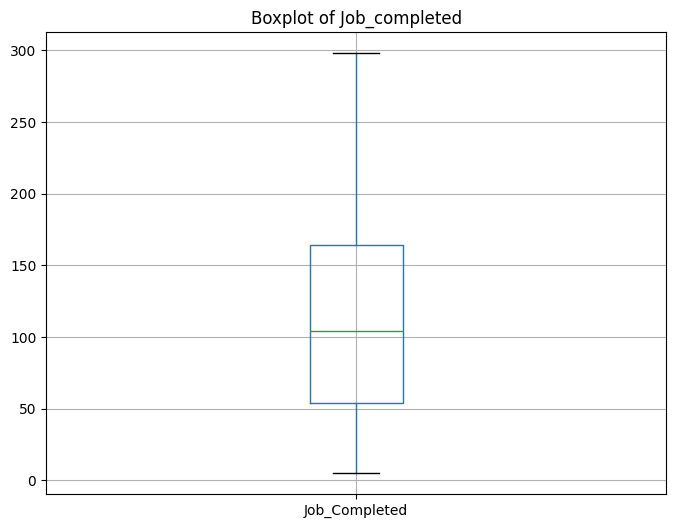

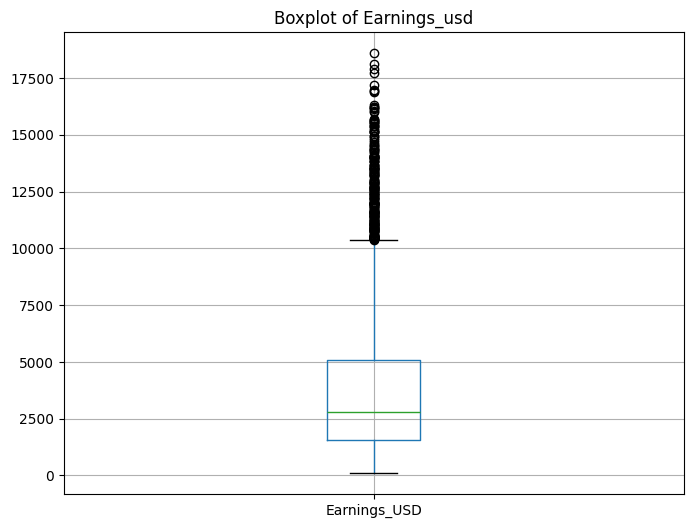

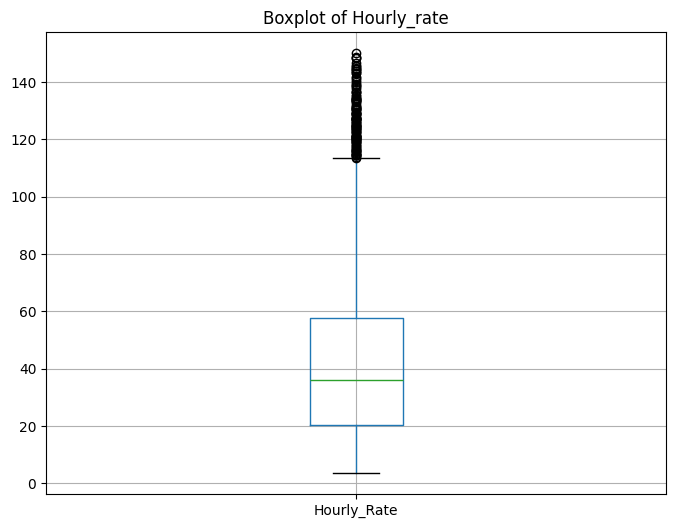

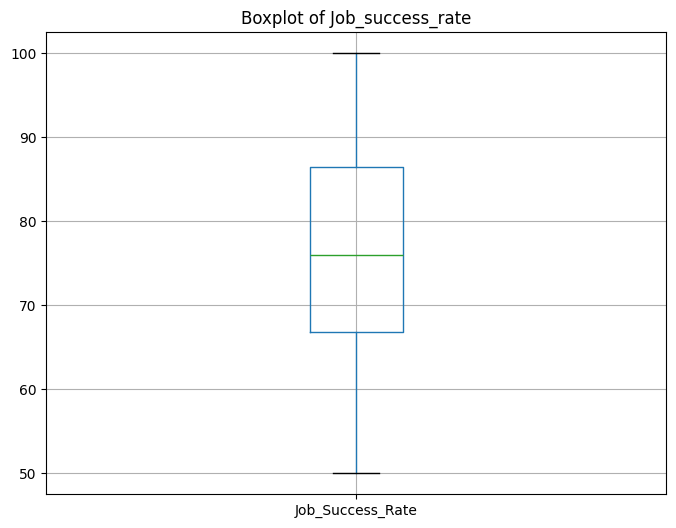

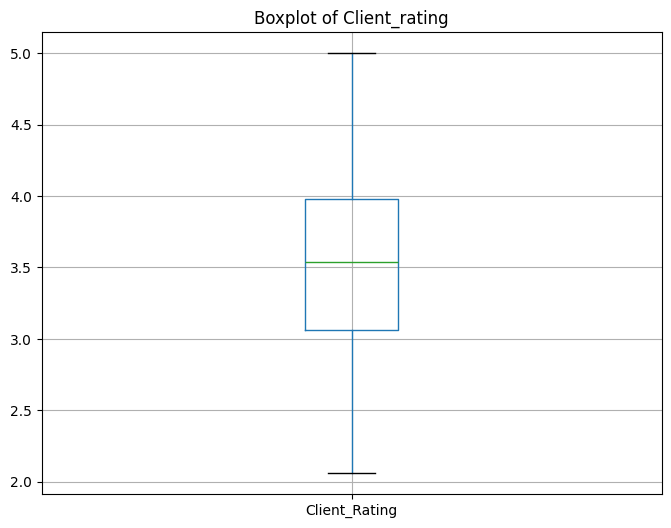

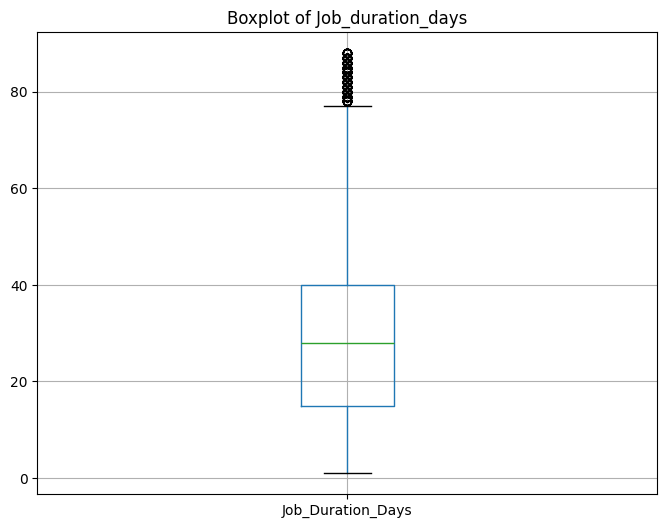

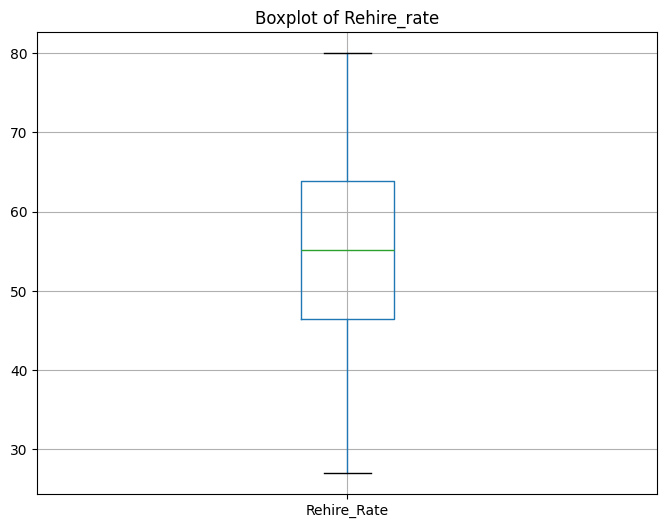

In [31]:
numerical_colums = ['Job_Completed','Earnings_USD','Hourly_Rate','Job_Success_Rate','Client_Rating','Job_Duration_Days','Rehire_Rate' ]

for column  in numerical_colums:
  plt.figure(figsize=(8,6))
  df3.boxplot(column = [column], vert = True)
  plt.title(f'Boxplot of {column.capitalize()}')
  plt.show()

Now will check the outilesr with IQR also

In [32]:
def finding_outliers (column):
  Q1= df3[column].quantile(0.25)
  Q3 = df3[column].quantile(0.75)

  IQR = Q3-Q1
  lower_bound =Q1-(1.5 * IQR)
  upper_bound = Q3+(1.5*IQR)

  outilers = df3[(df3[column]<lower_bound)  | (df3[column]>upper_bound)]

  print(' ')
  print(f'finding outliers for {column}')
  return outilers[column]

In [33]:
for column in numerical_colums:
  outliers= finding_outliers(column)
  print(outliers)

 
finding outliers for Job_Completed
Series([], Name: Job_Completed, dtype: int64)
 
finding outliers for Earnings_USD
14      13829
32      11696
37      14491
119     12536
162     13506
        ...  
4947    11674
4951    14356
4958    13378
4967    12968
4978    13234
Name: Earnings_USD, Length: 218, dtype: int64
 
finding outliers for Hourly_Rate
109     115.42
135     148.31
140     113.83
162     120.58
188     117.07
         ...  
4857    115.72
4923    139.89
4945    138.72
4950    125.63
4978    133.74
Name: Hourly_Rate, Length: 116, dtype: float64
 
finding outliers for Job_Success_Rate
Series([], Name: Job_Success_Rate, dtype: float64)
 
finding outliers for Client_Rating
Series([], Name: Client_Rating, dtype: float64)
 
finding outliers for Job_Duration_Days
26      80.0
37      80.0
41      88.0
61      85.0
69      82.0
        ... 
4705    81.0
4714    85.0
4720    79.0
4753    86.0
4941    82.0
Name: Job_Duration_Days, Length: 186, dtype: float64
 
finding outliers fo

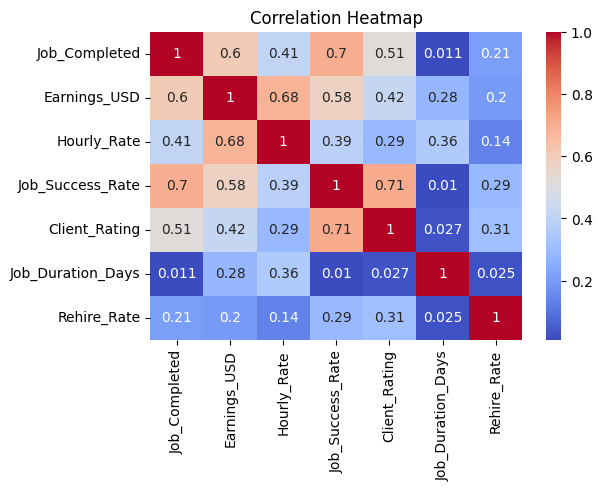

In [34]:
plt.figure(figsize=(6,4))
# Select only numerical columns for correlation
numerical_df = df3[numerical_colums]
sbn.heatmap(numerical_df.corr(), annot=True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [35]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4567 entries, 1 to 4999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Job_Category       4567 non-null   category
 1   Platform           4567 non-null   category
 2   Experience_Level   4567 non-null   category
 3   Job_Completed      4567 non-null   int64   
 4   Earnings_USD       4567 non-null   int64   
 5   Hourly_Rate        4567 non-null   float64 
 6   Job_Success_Rate   4567 non-null   float64 
 7   Client_Rating      4567 non-null   float64 
 8   Job_Duration_Days  4567 non-null   float64 
 9   Rehire_Rate        4567 non-null   float64 
dtypes: category(3), float64(5), int64(2)
memory usage: 299.5 KB


/tmp/ipykernel_4068/1279831050.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sorted_data = df3.groupby('Job_Category')['Earnings_USD'].mean().sort_values(ascending=False)


Text(0, 0.5, 'Average Earnings (USD)')

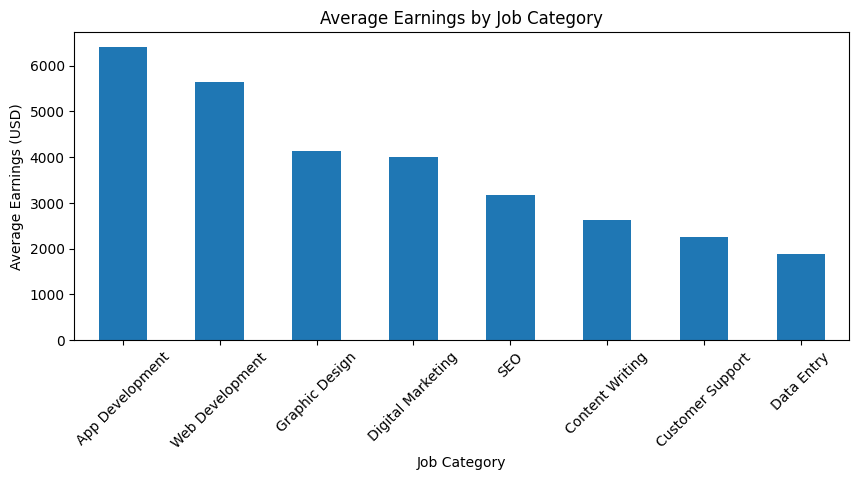

In [36]:
sorted_data = df3.groupby('Job_Category')['Earnings_USD'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,4))

plt.title('Average Earnings by Job Category')
sorted_data.plot (kind='bar')
plt.xlabel('Job Category')
plt.xticks(rotation=45)
plt.ylabel('Average Earnings (USD)')

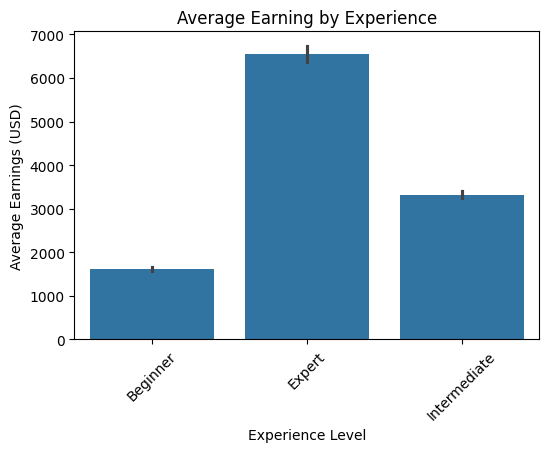

In [37]:
plt.figure(figsize=(6,4))
sbn.barplot(x='Experience_Level', y='Earnings_USD', data=df3)

plt.title('Average Earning by Experience')
plt.xlabel('Experience Level')
plt.ylabel('Average Earnings (USD)')
plt.xticks(rotation=45)

plt.show()

/tmp/ipykernel_4068/1127116743.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sorted_value = df3.groupby('Platform')['Earnings_USD'].mean().sort_values(ascending=False)


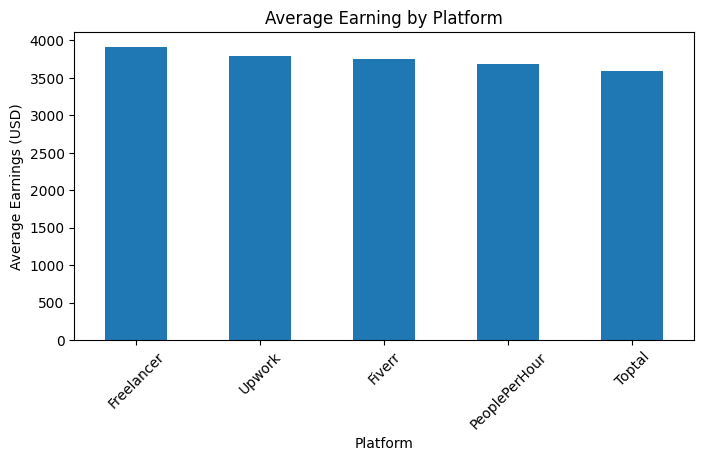

In [38]:
sorted_value = df3.groupby('Platform')['Earnings_USD'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
sorted_value.plot(kind='bar')
plt.title ("Average Earning by Platform")
plt.xlabel('Platform')
plt.ylabel('Average Earnings (USD)')
plt.xticks(rotation=45)
plt.show()

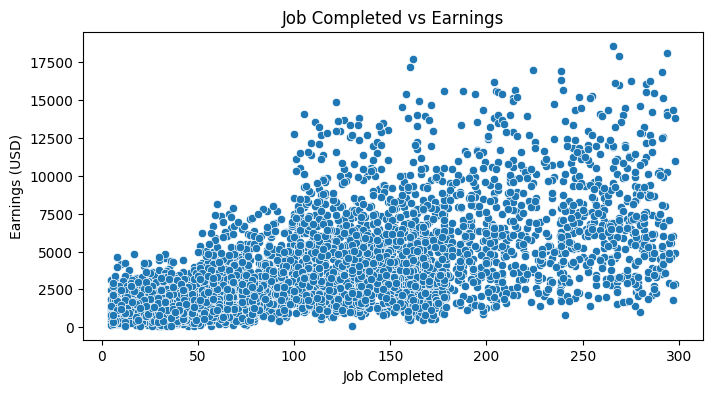

In [39]:
plt.figure(figsize=(8,4))
sbn.scatterplot(x= 'Job_Completed', y='Earnings_USD', data=df3)
plt.title('Job Completed vs Earnings')
plt.xlabel('Job Completed')
plt.ylabel('Earnings (USD)')
plt.show()

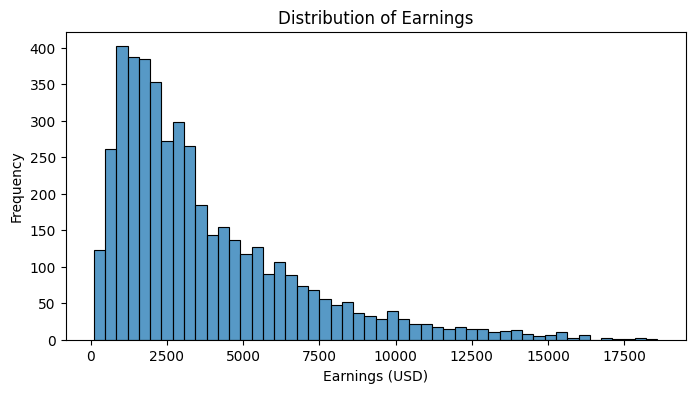

In [40]:
plt.figure(figsize=(8,4))
sbn.histplot(df3['Earnings_USD'], bins=50)

plt.title('Distribution of Earnings')
plt.xlabel('Earnings (USD)')
plt.ylabel('Frequency')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

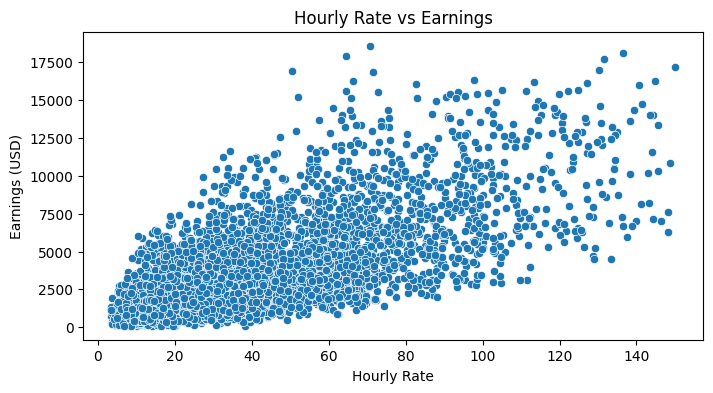

In [41]:
plt.figure(figsize=(8,4))
sbn.scatterplot(x='Hourly_Rate', y='Earnings_USD', data=df3)
plt.title('Hourly Rate vs Earnings')
plt.xlabel('Hourly Rate')
plt.ylabel('Earnings (USD)')
plt.show

In [99]:
df4 = df3.copy()
df4['Job_Duration_Days'].sort_values(ascending=False)

,Job_Duration_Days
3239,88.0
3053,88.0
4452,88.0
2457,88.0
41,88.0
...,...
4306,1.0
4301,1.0
1832,1.0
2926,1.0


feature ingineering for compute project complexity

In [100]:
df4['project complexity'] = pd.cut(
    df4['Job_Duration_Days'],
    bins=[0,15,30,60,75, 90],
    labels = [1,2,3,4,5]
)

In [101]:
df4.head()

,Job_Category,Platform,Experience_Level,Job_Completed,Earnings_USD,Hourly_Rate,Job_Success_Rate,Client_Rating,Job_Duration_Days,Rehire_Rate,project complexity
1,Digital Marketing,PeoplePerHour,Intermediate,70,3052,50.87,80.29,2.92,25.0,44.28,2
3,Customer Support,PeoplePerHour,Expert,107,3930,13.13,98.19,3.95,40.0,69.78,3
4,SEO,Toptal,Expert,261,6988,49.17,98.53,4.89,15.0,47.84,1
5,Digital Marketing,Upwork,Beginner,45,958,24.37,54.13,2.14,9.0,57.00,1
6,Graphic Design,Freelancer,Beginner,9,1205,49.66,66.28,3.70,9.0,60.06,1


above from heatmap we can get decision to remove some cpolumns like ,Job_Duration_Days, Rehire_Rate


In [102]:
drop_columns = ['Job_Duration_Days','Rehire_Rate']
df4.drop(drop_columns, inplace=True, axis=1)


In [103]:
df5 = df4.copy()
df5.head()

,Job_Category,Platform,Experience_Level,Job_Completed,Earnings_USD,Hourly_Rate,Job_Success_Rate,Client_Rating,project complexity
1,Digital Marketing,PeoplePerHour,Intermediate,70,3052,50.87,80.29,2.92,2
3,Customer Support,PeoplePerHour,Expert,107,3930,13.13,98.19,3.95,3
4,SEO,Toptal,Expert,261,6988,49.17,98.53,4.89,1
5,Digital Marketing,Upwork,Beginner,45,958,24.37,54.13,2.14,1
6,Graphic Design,Freelancer,Beginner,9,1205,49.66,66.28,3.70,1


In [104]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4567 entries, 1 to 4999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Job_Category        4567 non-null   category
 1   Platform            4567 non-null   category
 2   Experience_Level    4567 non-null   category
 3   Job_Completed       4567 non-null   int64   
 4   Earnings_USD        4567 non-null   int64   
 5   Hourly_Rate         4567 non-null   float64 
 6   Job_Success_Rate    4567 non-null   float64 
 7   Client_Rating       4567 non-null   float64 
 8   project complexity  4567 non-null   category
dtypes: category(4), float64(3), int64(2)
memory usage: 232.8 KB


In [105]:
df5['project complexity']=df5['project complexity'].astype('float')

In [106]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4567 entries, 1 to 4999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Job_Category        4567 non-null   category
 1   Platform            4567 non-null   category
 2   Experience_Level    4567 non-null   category
 3   Job_Completed       4567 non-null   int64   
 4   Earnings_USD        4567 non-null   int64   
 5   Hourly_Rate         4567 non-null   float64 
 6   Job_Success_Rate    4567 non-null   float64 
 7   Client_Rating       4567 non-null   float64 
 8   project complexity  4567 non-null   float64 
dtypes: category(3), float64(4), int64(2)
memory usage: 263.8 KB


now will encode the categorical columns

In [107]:
# now will encode the categorical columns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# ✅ Fix Experience Level — logical order
oe = OrdinalEncoder(categories=[['Beginner','Intermediate','Expert']])
df5['Experience_Level'] = oe.fit_transform(df5[['Experience_Level']])

# Job Category and Platform — label encoding same as before
le = LabelEncoder()
df5['Job_Category'] = le.fit_transform(df5['Job_Category'])
df5['Platform']     = le.fit_transform(df5['Platform'])

df6 = df5.copy()
df6.head()

,Job_Category,Platform,Experience_Level,Job_Completed,Earnings_USD,Hourly_Rate,Job_Success_Rate,Client_Rating,project complexity
1,4,2,1.0,70,3052,50.87,80.29,2.92,2.0
3,2,2,2.0,107,3930,13.13,98.19,3.95,3.0
4,6,3,2.0,261,6988,49.17,98.53,4.89,1.0
5,4,4,0.0,45,958,24.37,54.13,2.14,1.0
6,5,1,0.0,9,1205,49.66,66.28,3.70,1.0


In [108]:
df6 = df5.copy()
df6.head()

,Job_Category,Platform,Experience_Level,Job_Completed,Earnings_USD,Hourly_Rate,Job_Success_Rate,Client_Rating,project complexity
1,4,2,1.0,70,3052,50.87,80.29,2.92,2.0
3,2,2,2.0,107,3930,13.13,98.19,3.95,3.0
4,6,3,2.0,261,6988,49.17,98.53,4.89,1.0
5,4,4,0.0,45,958,24.37,54.13,2.14,1.0
6,5,1,0.0,9,1205,49.66,66.28,3.70,1.0


In [109]:
df4.value_counts('Job_Category')

,count
Job_Category,
Digital Marketing,623
Customer Support,590
SEO,590
Graphic Design,568
Content Writing,566
Web Development,546
App Development,544
Data Entry,540


In [110]:
df4.value_counts('Platform')

,count
Platform,
Upwork,971
PeoplePerHour,905
Toptal,903
Fiverr,901
Freelancer,887


In [111]:
#after encoding we can see all the columns

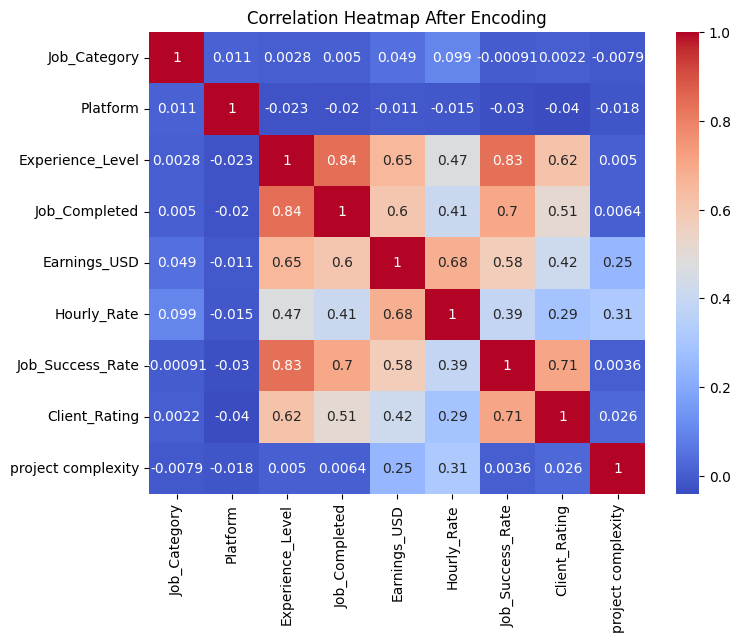

In [112]:
plt.figure(figsize=(8, 6))  # also make it bigger — more columns now!
sbn.heatmap(df6.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap After Encoding")
plt.show()

In [113]:
#platform is minus so will remove from entire model
#job category want for user experience
#remove job success rate. client rating

In [114]:
removing_columns = ['Platform','Job_Success_Rate','Client_Rating']
df6.drop(removing_columns, inplace=True, axis=1)

In [115]:
df7 = df6.copy()
df7.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4567 entries, 1 to 4999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Job_Category        4567 non-null   int64  
 1   Experience_Level    4567 non-null   float64
 2   Job_Completed       4567 non-null   int64  
 3   Earnings_USD        4567 non-null   int64  
 4   Hourly_Rate         4567 non-null   float64
 5   project complexity  4567 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 249.8 KB


now will create dependant and independant variable

In [116]:
X = ['Job_Category','Experience_Level','Job_Completed','Hourly_Rate','project complexity']
X

['Job_Category',
 'Experience_Level',
 'Job_Completed',
 'Hourly_Rate',
 'project complexity']

In [117]:
y = ['Earnings_USD']
y

['Earnings_USD']

train and test the dataset using split and cross validaion

In [118]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df7[X], df7[y], test_size=0.2, random_state=10)

In [119]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train, y_train)
reg.score(X_test, y_test)

0.623518961400873

In [120]:
reg.score(X_train, y_train)

0.6250184864774286

In [121]:
from sklearn.model_selection import cross_val_score, ShuffleSplit

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
cross_val =cross_val_score(LinearRegression(), df7[X], df7[y], cv=cv)
cross_val

array([0.59885326, 0.59450533, 0.62581484, 0.61479771, 0.61534327])

In [122]:
print(f"Mean R²  : {cross_val.mean():.4f}")
print(f"Std      : {cross_val.std():.4f}")
print(f"Min R²   : {cross_val.min():.4f}")
print(f"Max R²   : {cross_val.max():.4f}")

Mean R²  : 0.6099
Std      : 0.0115
Min R²   : 0.5945
Max R²   : 0.6258


In [124]:
from sklearn.model_selection import GridSearchCV, ShuffleSplit
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

def find_best_model_using_grid_search_cv(X, y):
    algos = {
        'linear_regression': {
            'model': LinearRegression(),
            'params': {
                'fit_intercept': [True, False]
            }
        },
        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [1, 2],
                'selection': ['random', 'cyclic']
            }
        },
        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion'  : ['squared_error', 'friedman_mse'],
                'splitter'   : ['best', 'random'],
                'max_depth'  : [5, 10, 15, None],
            }
        },
        'random_forest': {
            'model': RandomForestRegressor(),
            'params': {
                'n_estimators': [10, 50, 100],
                'max_depth'   : [5, 10, None],
                'criterion'   : ['squared_error', 'friedman_mse'],
            }
        }
    }

    scores     = []
    best_model = None
    best_score = -np.inf
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

    for algo_name, config in algos.items():
        gs = GridSearchCV(config['model'], config['params'],
                         cv=cv, return_train_score=False)
        gs.fit(X, y)
        scores.append({
            'model'      : algo_name,
            'best_score' : gs.best_score_,
            'best_params': gs.best_params_
        })
        print(f"✅ {algo_name} done → R²: {gs.best_score_:.4f}")

        if gs.best_score_ > best_score:
            best_score = gs.best_score_
            best_model = gs.best_estimator_

    print(f"\n🏆 Best Model : {type(best_model).__name__}")
    print(f"🏆 Best R²    : {best_score:.4f}")

    return pd.DataFrame(scores, columns=['model', 'best_score', 'best_params']), best_model

results, final_model = find_best_model_using_grid_search_cv(df7[X], df7[y])
print(results)
print("\nFinal model:", type(final_model).__name__)

✅ linear_regression done → R²: 0.6099
✅ lasso done → R²: 0.6099
✅ decision_tree done → R²: 0.7104


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

✅ random_forest done → R²: 0.7177

🏆 Best Model : RandomForestRegressor
🏆 Best R²    : 0.7177
               model  best_score  \
0  linear_regression    0.609863   
1              lasso    0.609904   
2      decision_tree    0.710440   
3      random_forest    0.717697   

                                         best_params  
0                            {'fit_intercept': True}  
1                {'alpha': 2, 'selection': 'random'}  
2  {'criterion': 'squared_error', 'max_depth': 5,...  
3  {'criterion': 'friedman_mse', 'max_depth': 5, ...  

Final model: RandomForestRegressor


In [128]:

# Check your encoded values first
print("Job_Category values:", df7['Job_Category'].unique())
print("Experience_Level values:", df7['Experience_Level'].unique())

Job_Category values: [4 2 6 5 3 0 1 7]
Experience_Level values: [1. 2. 0.]


In [129]:
def predict_earnings(job_category, experience_level, job_completed, hourly_rate, project_complexity):

    x = np.zeros(5)
    x[0] = job_category
    x[1] = experience_level
    x[2] = job_completed
    x[3] = hourly_rate
    x[4] = project_complexity

    return final_model.predict([x])[0]


In [132]:
# Job Category mapping
print("Job Category Mapping:")
for i, cat in enumerate(df3['Job_Category'].cat.categories):
    print(f"  {i} → {cat}")

print()

# Experience Level mapping — hardcoded correct order from OrdinalEncoder
print("Experience Level Mapping:")
experience_mapping = {0: 'Beginner', 1: 'Intermediate', 2: 'Expert'}
for i, exp in experience_mapping.items():
    print(f"  {i} → {exp}")

Job Category Mapping:
  0 → App Development
  1 → Content Writing
  2 → Customer Support
  3 → Data Entry
  4 → Digital Marketing
  5 → Graphic Design
  6 → SEO
  7 → Web Development

Experience Level Mapping:
  0 → Beginner
  1 → Intermediate
  2 → Expert


In [134]:
predict_earnings(
    job_category = 1,
    experience_level=0,
    job_completed=100,
    hourly_rate=20,
    project_complexity=3
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


np.float64(1112.9053856813534)

In [135]:
predict_earnings(
    job_category = 1,
    experience_level=1,
    job_completed=100,
    hourly_rate=20,
    project_complexity=3
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


np.float64(2188.337242022725)

In [136]:
predict_earnings(
    job_category = 1,
    experience_level=2,
    job_completed=100,
    hourly_rate=20,
    project_complexity=3
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


np.float64(4338.175434267494)

In [137]:
import pickle

with open('freelancer_model.pickle', 'wb') as f:
    pickle.dump(final_model, f)

print("✅ Model saved as freelancer_model.pickle")

✅ Model saved as freelancer_model.pickle


In [138]:
import json

columns = {
    'data_columns'     : ['job_category', 'experience_level',
                          'job_completed', 'hourly_rate',
                          'project_complexity'],
    'job_categories'   : list(df3['Job_Category'].cat.categories),
    'experience_levels': ['Beginner', 'Intermediate', 'Expert']
}

with open('columns.json', 'w') as f:
    f.write(json.dumps(columns))

print("✅ Columns saved as columns.json")

✅ Columns saved as columns.json


In [139]:
from google.colab import files

files.download('freelancer_model.pickle')
files.download('columns.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>